# **Segmentación de bosques – Test 4 Áreas protegidas -Cundinamarca**
by Diana Millan

# 1. LIBRERIAS

Se instalan las librerías necesarias para el procesamiento y análisis de datos geoespaciales, manejo de imágenes y uso de modelos de aprendizaje profundo.

* rasterio, geopandas, shapely, tifffile, pillow, opencv-python →
Para lectura, escritura, manipulación y visualización de imágenes y datos georreferenciados (GeoTIFF, shapefiles, etc.).

* torch, torchvision → Framework de PyTorch para trabajar con redes neuronales profundas, instalación optimizada con soporte CUDA 12.1 para usar GPU.

* satlaspretrain-models → Librería oficial que permite cargar y usar modelos preentrenados de la iniciativa SATLAS para tareas como segmentación en imágenes satelitales.

In [2]:
!pip -q install rasterio geopandas shapely tifffile pillow opencv-python \
                torch torchvision --extra-index-url https://download.pytorch.org/whl/cu121
!pip -q install satlaspretrain-models

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 82.9 MB/s eta 0:00:00


# 2. PREPARAR EL ENTORNO PARA LA INFERENCIA

Se clona el repositorio dpr-zoo-segmentation-hub desde GitHub (gitclone) y se cambia el directorio de trabajo a la carpeta descargada.

* Se va usar Satlas Amazon epoch 30  este archivo se usa para las inferencias y para transfer learning
* Luego se monta el google dirve para las imagenes que se van a usar de inferencia y descargar los resultados


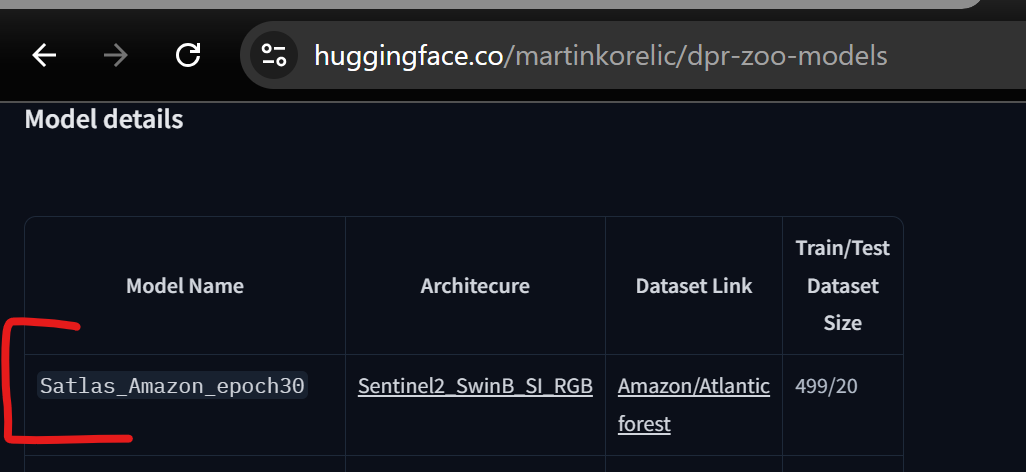

In [3]:
!git clone https://github.com/DPR25/dpr-zoo-segmentation-hub.git
%cd dpr-zoo-segmentation-hub

Cloning into 'dpr-zoo-segmentation-hub'...
remote: Enumerating objects: 354, done.
remote: Counting objects: 100% (354/354), done.
remote: Compressing objects: 100% (268/268), done.
remote: Total 354 (delta 103), reused 332 (delta 81), pack-reused 0 (from 0)
Receiving objects: 100% (354/354), 39.73 MiB | 21.23 MiB/s, done.
Resolving deltas: 100% (103/103), done.
/content/dpr-zoo-segmentation-hub


In [4]:
# descargar pesos al directorio esperado
import pathlib, urllib.request

pathlib.Path("app/saved_models").mkdir(parents=True, exist_ok=True)

# Satlas (bosque/no-bosque, RGB B02,B03,B04)
URL = "https://huggingface.co/martinkorelic/dpr-zoo-models/resolve/main/Satlas_Amazon_epoch30.pth"
OUT = "app/saved_models/Satlas_Amazon_epoch30.pth"

# (opcional) alternativa DeepLabV3 AiTLAS:
# URL = "https://huggingface.co/martinkorelic/dpr-zoo-models/resolve/main/Aitlas_Amazon.pth.tar"
# OUT = "app/saved_models/Aitlas_Amazon.pth.tar"

urllib.request.urlretrieve(URL, OUT)
print("Pesos descargados en:", OUT)


Pesos descargados en: app/saved_models/Satlas_Amazon_epoch30.pth


In [5]:
# Montar Google Drive y definir ruta de la imagen exportada desde GEE
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#4. TRANSFER LEARNING

1) Configuración y rutas

In [6]:
# ====== CONFIGURACIÓN Y RUTAS ======
import os, glob, re, random, json, math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import rasterio
from rasterio.features import rasterize
import geopandas as gpd

import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt

# Rutas base (ajústalas si lo necesitas)
IMG_DIR     = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/image"
LABELS_DIR  = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/labels"
OUT_DIR     = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune"

os.makedirs(OUT_DIR, exist_ok=True)

# Hiperparámetros principales
TILE_SIZE   = 512           # tamaño de recorte
BATCH_SIZE  = 2
EPOCHS      = 20            # 5 congelado + 15 afinando todo
LR_BACKBONE = 1e-4
LR_HEAD     = 5e-4
FREEZE_EPOCHS = 5           # épocas con backbone congelado

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device


device(type='cpu')

Ver si todas las imagenes tienen sus etiquetas

2) Emparejar imágenes con labels (id) y split train/val

In [7]:
# ====== EMPAREJAR IMAGENES CON LABELS ======
def extract_id(text):
    m = re.search(r'id[_\-]?(\d+)', text, re.IGNORECASE)
    if m: return str(int(m.group(1)))
    m2 = re.search(r'(\d+)', text)
    return str(int(m2.group(1))) if m2 else None

# recolectar imágenes .tif/.tiff
imgs = sorted(glob.glob(os.path.join(IMG_DIR, "*.tif")) +
              glob.glob(os.path.join(IMG_DIR, "*.tiff")))

pairs = []
for ip in imgs:
    iid = extract_id(os.path.basename(ip))
    if iid is None:
        continue
    lab = os.path.join(LABELS_DIR, f"label_{iid}.geojson")
    if os.path.exists(lab):
        pairs.append((ip, lab, iid))

assert len(pairs) > 0, "No se encontraron pares imagen+label."

# Split por escenas (80/20)
random.shuffle(pairs)
n_train = max(1, int(0.8 * len(pairs)))
train_pairs = pairs[:n_train]
val_pairs   = pairs[n_train:]

len(train_pairs), len(val_pairs), [p[2] for p in val_pairs]


(31, 8, ['1050', '1051', '1109', '1251', '1301', '1371', '1001', '1086'])

3) Utilidades: lectura de imagen, rasterizado del GeoJSON y normalización

In [9]:
# ====== UTILIDADES DE LECTURA Y RASTERIZADO ======
def read_rgb_bgrn_as_rgb(path, perc_rescale=True):
    """
    Lee B2,B3,B4,(B8) y devuelve RGB = (B4,B3,B2) en [0,1].
    """
    with rasterio.open(path) as src:
        count = src.count
        if count < 3:
            raise ValueError(f"{path} tiene menos de 3 bandas.")
        B2, B3, B4 = src.read([1,2,3]).astype(np.float32)
        mx = max(float(B2.max()), float(B3.max()), float(B4.max()))
        scale = 10000.0 if mx > 5000 else (255.0 if mx > 1.5 else 1.0)
        B2, B3, B4 = B2/scale, B3/scale, B4/scale
        rgb = np.stack([B4, B3, B2], axis=0)  # (3,H,W)
        if perc_rescale:
            arr = rgb.copy()
            for c in range(3):
                p2, p98 = np.percentile(arr[c], [2,98])
                if p98 > p2:
                    arr[c] = np.clip((arr[c]-p2)/(p98-p2), 0, 1)
            rgb = arr
        transform, crs = src.transform, src.crs
    return rgb, transform, crs  # (3,H,W), Affine, CRS

def rasterize_geojson_to_match(geojson_path, height, width, transform, crs):
    """
    Rasteriza el GeoJSON (bosque=1) a la grilla de la imagen.
    """
    gdf = gpd.read_file(geojson_path)
    if gdf.empty:
        return np.zeros((height, width), dtype=np.uint8)

    if gdf.crs is None:
        gdf_aligned = gdf
    else:
        gdf_aligned = gdf.to_crs(crs) if str(gdf.crs) != str(crs) else gdf

    shapes = [(geom, 1) for geom in gdf_aligned.geometry if geom is not None and not geom.is_empty]
    if len(shapes) == 0:
        return np.zeros((height, width), dtype=np.uint8)

    mask = rasterize(
        shapes=shapes,
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8',
        all_touched=False
    )
    return mask


4) Dataset con augmentations (flips, rotaciones 90°, recorte aleatorio, brillo/contraste)

In [10]:
# ====== DATASET CON AUGMENTATIONS (CORREGIDO + REPORTE FINAL TOTAL) ======
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF

class SegmentationRandomCrops(Dataset):
    def __init__(self, pairs, tile_size=512, train=True, n_crops_per_image=120, seed=42, extra_aug=False):
        """
        pairs: lista (img_path, label_path, id)
        n_crops_per_image: recortes aleatorios por imagen y por época
        extra_aug: si True, aplica augmentations adicionales (gamma/ruido)
        """
        self.pairs   = pairs
        self.tile    = tile_size
        self.train   = train
        self.n_crops = n_crops_per_image
        self.extra_aug = extra_aug
        self.rng = random.Random(seed)

        # precargar metadatos mínimos
        self.cache = []
        for ip, lp, _ in pairs:
            with rasterio.open(ip) as src:
                H, W = src.height, src.width
                tr, crs = src.transform, src.crs
            self.cache.append((ip, lp, H, W, tr, crs))

        # índice lógico: cada imagen se “repite” n_crops veces
        self.index = []
        for i in range(len(self.cache)):
            self.index.extend([i] * self.n_crops)

    def __len__(self):
        return len(self.index)

    def _random_augment_image_mask(self, img_t, mask_t):
        # flips
        if self.rng.random() < 0.5:
            img_t = TF.hflip(img_t); mask_t = TF.hflip(mask_t)
        if self.rng.random() < 0.5:
            img_t = TF.vflip(img_t); mask_t = TF.vflip(mask_t)

        # rotaciones k*90°
        k = self.rng.choice([0, 1, 2, 3])
        if k > 0:
            img_t = torch.rot90(img_t, k, [1, 2])
            mask_t = torch.rot90(mask_t, k, [1, 2])

        # brillo/contraste
        if self.rng.random() < 0.7:
            img_t = TF.adjust_brightness(img_t, brightness_factor=self.rng.uniform(0.8, 1.25))
        if self.rng.random() < 0.7:
            img_t = TF.adjust_contrast(img_t, contrast_factor=self.rng.uniform(0.8, 1.25))

        # augmentations extra
        if self.extra_aug:
            if self.rng.random() < 0.5:
                gamma = self.rng.uniform(0.8, 1.2)
                img_t = torch.clamp(img_t ** gamma, 0.0, 1.0)
            if self.rng.random() < 0.5:
                sigma = self.rng.uniform(0.0, 0.03)
                img_t = torch.clamp(img_t + sigma * torch.randn_like(img_t), 0.0, 1.0)

        return img_t, mask_t

    def __getitem__(self, idx):
        j = self.index[idx]
        ip, lp, H, W, tr, crs = self.cache[j]

        rgb, transform, crs_img = read_rgb_bgrn_as_rgb(ip, perc_rescale=True)
        _, H, W = rgb.shape
        gt = rasterize_geojson_to_match(lp, H, W, transform, crs_img)

        th, tw = self.tile, self.tile
        if (H <= th) or (W <= tw):
            pad_h = max(0, th - H); pad_w = max(0, tw - W)
            rgb = np.pad(rgb, ((0,0),(0,pad_h),(0,pad_w)), mode='reflect')
            gt  = np.pad(gt,  ((0,pad_h),(0,pad_w)), mode='constant', constant_values=0)
            _, H, W = rgb.shape

        y = self.rng.randint(0, H - th)
        x = self.rng.randint(0, W - tw)
        rgb_crop = rgb[:, y:y+th, x:x+tw]
        gt_crop  = gt[y:y+th, x:x+tw]

        img_t  = torch.from_numpy(rgb_crop).float()
        mask_t = torch.from_numpy(gt_crop).long().unsqueeze(0)

        if self.train:
            img_t, mask_t = self._random_augment_image_mask(img_t, mask_t)

        return img_t, mask_t.squeeze(0)

    # helpers
    @property
    def num_images(self): return len(self.cache)
    @property
    def crops_per_image(self): return self.n_crops


# ====== CONSTRUCCIÓN + REPORTE FINAL ======
N_CROPS_TRAIN = 200
N_CROPS_VAL   = 40

train_ds = SegmentationRandomCrops(train_pairs, tile_size=TILE_SIZE, train=True,
                                   n_crops_per_image=N_CROPS_TRAIN, extra_aug=True)
val_ds   = SegmentationRandomCrops(val_pairs,   tile_size=TILE_SIZE, train=False,
                                   n_crops_per_image=N_CROPS_VAL,   extra_aug=False)

train_samples = len(train_ds)
val_samples   = len(val_ds)
total_samples = train_samples + val_samples
total_imgs    = train_ds.num_images + val_ds.num_images
total_aug     = total_samples - total_imgs

# ==== Nuevo: cálculo del total "visto" en todas las épocas ====
total_epochs_seen = total_samples * EPOCHS

print("======= RESUMEN POST-AUGMENTATION =======")
print(f"Imágenes originales → total={total_imgs} | train={train_ds.num_images} | val={val_ds.num_images}")
print(f"Recortes por imagen → train={train_ds.crops_per_image} | val={val_ds.crops_per_image}")
print(f"Samples por época   → train={train_samples} | val={val_samples} | TOTAL={total_samples}")
print(f"Aumentos efectivos  → TOTAL_AUG = {total_aug}")
print(f"Batches/época       → train={math.ceil(train_samples/BATCH_SIZE)} | val={math.ceil(val_samples/BATCH_SIZE)}")
print(f"Épocas totales      → {EPOCHS}")
print(f"Total de 'imágenes' vistas por el modelo = {total_samples} × {EPOCHS} = {total_epochs_seen}")
print("=============================================================")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, drop_last=False)


======= RESUMEN POST-AUGMENTATION =======
Imágenes originales → total=39 | train=31 | val=8
Recortes por imagen → train=200 | val=40
Samples por época   → train=6200 | val=320 | TOTAL=6520
Aumentos efectivos  → TOTAL_AUG = 6481
Batches/época       → train=3100 | val=160
Épocas totales      → 20
Total de 'imágenes' vistas por el modelo = 6520 × 20 = 130400


In [9]:
# ====== VISUALIZAR AUGMENTATIONS ======
import matplotlib.pyplot as plt

# Tomamos 3 ejemplos al azar del dataset de entrenamiento
n_examples = 3
for i in range(n_examples):
    img_t, mask_t = train_ds[random.randint(0, len(train_ds)-1)]

    # A tensores → numpy para visualizar
    img_np  = img_t.permute(1,2,0).numpy()   # (H,W,3)
    mask_np = mask_t.numpy()                 # (H,W)

    # Normalizar a [0,1] para mostrar
    img_np = np.clip(img_np, 0, 1)

    # Plot
    fig, ax = plt.subplots(1, 2, figsize=(10,5))
    ax[0].imshow(img_np)
    ax[0].set_title("Imagen augmentada")
    ax[0].axis("off")

    # Overlay etiqueta
    ax[1].imshow(img_np)
    mask_overlay = np.zeros((*mask_np.shape, 4), dtype=np.float32)
    mask_overlay[mask_np==1] = [0,1,0,0.5]  # verde semitransparente
    ax[1].imshow(mask_overlay)
    ax[1].set_title("Imagen + máscara (verde)")
    ax[1].axis("off")

    plt.tight_layout()
    plt.show()


Output hidden; open in https://colab.research.google.com to view.

5) DataLoaders (train/val)

In [11]:
# ====== DATALOADERS ======
# Aumenta n_crops_per_image si quieres más pasos por época con pocas imágenes
train_ds = SegmentationRandomCrops(train_pairs, tile_size=TILE_SIZE, train=True,  n_crops_per_image=30)
val_ds   = SegmentationRandomCrops(val_pairs,   tile_size=TILE_SIZE, train=False, n_crops_per_image=10)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

len(train_ds), len(val_ds)


(930, 80)

6) Modelo Satlas + pérdidas y optimizador (LR diferenciado, congelamiento inicial)

In [13]:
# ====== MODELO + OPTIMIZADOR ======
import satlaspretrain_models as spm

# Cargar modelo base (mismas specs que usaste en inferencia)
weights_manager = spm.Weights()
model = weights_manager.get_pretrained_model(
    model_identifier="Sentinel2_SwinB_SI_RGB",
    fpn=True, head=spm.Head.SEGMENT, num_categories=2
)

# Cargar checkpoint de Amazon (seguimos desde ahí)
ckpt = torch.load("app/saved_models/Satlas_Amazon_epoch30.pth", map_location="cpu")
model.load_state_dict(ckpt.get("state_dict", ckpt), strict=False)
model = model.to(device)

# Separar parámetros: backbone/FPN vs cabeza
backbone_params = []
head_params = []
for n, p in model.named_parameters():
    if any(k in n.lower() for k in ["decoder", "head", "logits", "seg", "classifier"]):
        head_params.append(p)
    else:
        backbone_params.append(p)

# Congelar backbone inicialmente
for p in backbone_params: p.requires_grad = False

# Pérdidas (CE + Dice opcional, aquí simple CE para clase única binaria en 2 canales)
criterion = nn.CrossEntropyLoss()

# Optimizador con LR diferenciado
optimizer = torch.optim.Adam([
    {"params": backbone_params, "lr": LR_BACKBONE},
    {"params": head_params,     "lr": LR_HEAD},
])


RuntimeError: Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.

7) Métrica IoU e implementación del ciclo de entrenamiento (con “descongelado”)

[01/20] train_loss=0.4881 val_loss=0.4550 | train_IoU=0.374 val_IoU=0.385
  ✅ Nuevo mejor modelo (val IoU=0.385) guardado.
[02/20] train_loss=0.4874 val_loss=0.4557 | train_IoU=0.379 val_IoU=0.378
[03/20] train_loss=0.4857 val_loss=0.4535 | train_IoU=0.384 val_IoU=0.401
  ✅ Nuevo mejor modelo (val IoU=0.401) guardado.
[04/20] train_loss=0.4865 val_loss=0.4535 | train_IoU=0.377 val_IoU=0.399
[05/20] train_loss=0.4850 val_loss=0.4539 | train_IoU=0.381 val_IoU=0.385
[06/20] train_loss=0.4309 val_loss=0.4239 | train_IoU=0.546 val_IoU=0.557
  ✅ Nuevo mejor modelo (val IoU=0.557) guardado.
[07/20] train_loss=0.4099 val_loss=0.4303 | train_IoU=0.598 val_IoU=0.544
[08/20] train_loss=0.3938 val_loss=0.4445 | train_IoU=0.651 val_IoU=0.511
[09/20] train_loss=0.3814 val_loss=0.4413 | train_IoU=0.700 val_IoU=0.502
[10/20] train_loss=0.3732 val_loss=0.4372 | train_IoU=0.733 val_IoU=0.525
[11/20] train_loss=0.3672 val_loss=0.4455 | train_IoU=0.759 val_IoU=0.530
[12/20] train_loss=0.3630 val_loss=0.43

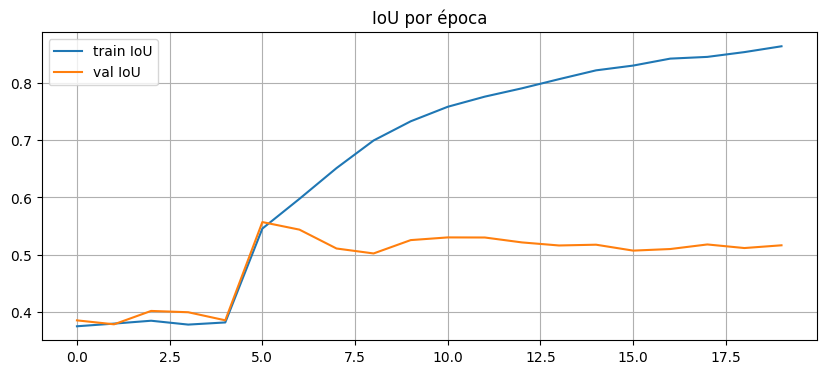

In [12]:
# ====== METRICA IoU Y TRAIN LOOP ======
def iou_from_logits(logits, target):
    """
    logits: (B,2,H,W), target: (B,H,W) en {0,1}
    """
    probs = torch.softmax(logits, dim=1)[:,1]        # (B,H,W) clase bosque
    pred  = (probs >= 0.5).long()
    inter = ((pred==1) & (target==1)).sum(dim=[1,2]).float()
    union = ((pred==1) | (target==1)).sum(dim=[1,2]).float()
    iou   = torch.where(union>0, inter/union, torch.full_like(union, float('nan')))
    return iou.mean().item()

def run_epoch(dl, train=True):
    model.train(train)
    total_loss, total_iou, steps = 0.0, 0.0, 0
    for imgs, gts in dl:
        imgs = imgs.to(device)          # (B,3,H,W)
        gts  = gts.to(device)           # (B,H,W)

        with torch.set_grad_enabled(train):
            out = model(imgs)
            if isinstance(out,(tuple,list)): out = out[0]
            if isinstance(out,dict):
                out = out.get('out', out.get('logits',
                       next(v for v in out.values() if torch.is_tensor(v))))
            loss = criterion(out, gts)

        if train:
            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            optimizer.step()

        total_loss += loss.item()
        total_iou  += iou_from_logits(out, gts)
        steps += 1

    return total_loss/steps, total_iou/steps

best_val_iou = -1
history = {"train_loss":[], "val_loss":[], "train_iou":[], "val_iou":[]}

for epoch in range(1, EPOCHS+1):
    # Descongelar backbone después de FREEZE_EPOCHS
    if epoch == FREEZE_EPOCHS+1:
        for p in backbone_params:
            p.requires_grad = True
        # reajustar LR del backbone usando el "name" del param group
        for g in optimizer.param_groups:
            if g.get("name") == "backbone":
                g["lr"] = LR_BACKBONE

    tr_loss, tr_iou = run_epoch(train_dl, train=True)
    vl_loss, vl_iou = run_epoch(val_dl,   train=False)

    history["train_loss"].append(tr_loss); history["val_loss"].append(vl_loss)
    history["train_iou"].append(tr_iou);   history["val_iou"].append(vl_iou)

    print(f"[{epoch:02d}/{EPOCHS}] "
          f"train_loss={tr_loss:.4f} val_loss={vl_loss:.4f} | "
          f"train_IoU={tr_iou:.3f} val_IoU={vl_iou:.3f}")

    # guardar el mejor
    if (not math.isnan(vl_iou)) and (vl_iou > best_val_iou):
        best_val_iou = vl_iou
        torch.save(model.state_dict(), os.path.join(OUT_DIR, "best_finetuned.pth"))
        print(f"  ✅ Nuevo mejor modelo (val IoU={best_val_iou:.3f}) guardado.")

# Curvas
plt.figure(figsize=(10,4))
plt.plot(history["train_iou"], label="train IoU")
plt.plot(history["val_iou"],   label="val IoU")
plt.legend(); plt.title("IoU por época"); plt.grid(True); plt.show()


In [15]:
# ===========================================
#  EVALUACIÓN FINAL · CPU · SIN RE-ENTRENAR
#  (usa tu mismo modelo y tus pesos guardados)
# ===========================================

# 0) Montar Drive (si ya está montado no pasa nada)
from google.colab import drive
drive.mount('/content/drive')

# 1) Imports base
import os, glob, math, json
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix

device = torch.device("cpu")  # <— forzamos CPU

# ==== RUTAS (usa las tuyas ya definidas; si no, descomenta y ajusta) ====
# OUT_DIR = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune"

# 2) RECONSTRUIR EL MODELO EXACTO QUE USASTE (misma celda 5 de tu notebook)
#    Intentamos la misma API que ya usaste: satlaspretrain_models (spm)
import satlaspretrain_models as spm

weights_manager = spm.Weights()

# Intento 1: construir sin forzar CUDA (CPU-only), luego cargar TUS pesos fine-tuned
# Nota: si get_pretrained_model diera problemas en CPU, caemos a build_model.
try:
    model = weights_manager.get_pretrained_model(
        model_identifier="Sentinel2_SwinB_SI_RGB",
        fpn=True, head=spm.Head.SEGMENT, num_categories=2
    )
except RuntimeError as e:
    print("⚠️ get_pretrained_model falló en este runtime. Probando build_model()…\n", e)
    model = weights_manager.build_model(
        model_identifier="Sentinel2_SwinB_SI_RGB",
        fpn=True, head=spm.Head.SEGMENT, num_categories=2
    )

model = model.to(device).eval()

# 3) CARGAR TUS PESOS FINE-TUNED GUARDADOS EN DRIVE (CPU-safe)
best_path = os.path.join(OUT_DIR, "best_finetuned.pth")
candidates = []
if os.path.exists(best_path): candidates.append(best_path)
candidates += sorted(glob.glob(os.path.join(OUT_DIR, "model_T4_final_epoch*.pth")))

assert len(candidates) > 0, f"No encuentro pesos .pth en {OUT_DIR}. Asegúrate de haber guardado best_finetuned.pth o model_T4_final_epoch*.pth"

ckpt_path = candidates[0]
ckpt = torch.load(ckpt_path, map_location="cpu")
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
model.load_state_dict(state, strict=False)  # strict=False por si cambian claves menores
print(f"✅ Pesos cargados desde: {ckpt_path} (CPU)")

# 4) ASEGURAR val_loader. Si ya existe, lo usamos; si no, lo reconstruimos con 1 crop/imagen
from torch.utils.data import DataLoader
if 'val_loader' in globals():
    vloader = val_loader
elif 'val_dl' in globals():
    vloader = val_dl
else:
    assert 'val_pairs' in globals() and 'TILE_SIZE' in globals(), \
        "Faltan 'val_pairs' o 'TILE_SIZE'. Reejecuta la celda de emparejar/split y config."
    # Usa TU clase (la misma del notebook), sin augmentación, 1 crop por imagen
    val_ds_tmp = SegmentationRandomCrops(val_pairs, tile_size=TILE_SIZE, train=False, n_crops_per_image=1)
    vloader = DataLoader(val_ds_tmp, batch_size=1, shuffle=False)

# 5) MÉTRICAS + GRÁFICAS (PR/AP, IoU/Dice vs umbral, confusión, boxplot por escena)
metrics_dir = os.path.join(OUT_DIR, "metrics"); os.makedirs(metrics_dir, exist_ok=True)
all_probs, all_true, iou_por_escena = [], [], []

model.eval()
with torch.no_grad():
    for imgs, gts in vloader:
        imgs = imgs.to(device)              # (B,3,H,W)
        gts  = gts.to(device)               # (B,H,W)

        out = model(imgs)
        # estandariza salida
        if isinstance(out, (tuple, list)): out = out[0]
        if isinstance(out, dict):
            out = out.get('out', out.get('logits',
                   next(v for v in out.values() if torch.is_tensor(v))))

        probs = torch.softmax(out, dim=1)[:, 1]  # clase "bosque"
        pred05 = (probs >= 0.5).long()

        # IoU por imagen (thr 0.5)
        inter = ((pred05==1) & (gts==1)).sum(dim=[1,2]).float()
        union = ((pred05==1) | (gts==1)).sum(dim=[1,2]).float()
        iou_im = torch.where(union>0, inter/union, torch.zeros_like(union))
        iou_por_escena.extend(iou_im.cpu().numpy().tolist())

        # Acumular para PR y sweep de umbral
        all_probs.append(probs.cpu().numpy().ravel())
        all_true.append(gts.cpu().numpy().ravel())

all_probs = np.concatenate(all_probs, axis=0)
all_true  = np.concatenate(all_true,  axis=0).astype(np.uint8)

# (a) Curva PR + AP
prec, rec, thr = precision_recall_curve(all_true, all_probs)
ap = average_precision_score(all_true, all_probs)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, linewidth=2)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Curva Precisión–Recall (AP = {ap:.3f})")
plt.grid(True, ls="--", alpha=.5); plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "curve_PR_AP.png"), dpi=160); plt.show()

# (b) IoU y Dice vs umbral (barrido)
thresholds = np.linspace(0.05, 0.95, 19)
ious, dices = [], []
for t in thresholds:
    pred = (all_probs >= t).astype(np.uint8)
    tp = np.logical_and(pred==1, all_true==1).sum()
    fp = np.logical_and(pred==1, all_true==0).sum()
    fn = np.logical_and(pred==0, all_true==1).sum()
    inter = tp
    union = np.logical_or(pred==1, all_true==1).sum()
    iou   = inter/union if union>0 else 0.0
    dice  = (2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0.0
    ious.append(iou); dices.append(dice)

best_idx = int(np.argmax(ious))
best_thr = float(thresholds[best_idx])
best_iou = float(ious[best_idx])
best_dice = float(dices[best_idx])

plt.figure(figsize=(6,5))
plt.plot(thresholds, ious, marker="o", label="IoU")
plt.plot(thresholds, dices, marker="s", label="Dice")
plt.axvline(best_thr, ls="--", alpha=.6)
plt.xlabel("Umbral"); plt.ylabel("Métrica")
plt.title(f"IoU/Dice vs Umbral · mejor thr={best_thr:.2f} (IoU={best_iou:.3f}, Dice={best_dice:.3f})")
plt.legend(); plt.grid(True, ls="--", alpha=.5); plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "iou_dice_vs_threshold.png"), dpi=160)
plt.show()

# (c) Matriz de confusión al umbral óptimo
pred_best = (all_probs >= best_thr).astype(np.uint8)
cm = confusion_matrix(all_true, pred_best, labels=[0,1])  # [[TN, FP],[FN, TP]]
TN, FP, FN, TP = cm.ravel()
plt.figure(figsize=(4.5,4))
plt.imshow(cm, cmap="Blues")
plt.xticks([0,1], ["No bosque","Bosque"]); plt.yticks([0,1], ["No bosque","Bosque"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", fontsize=11)
plt.title(f"Matriz de confusión (thr={best_thr:.2f})")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "confusion_matrix_best_threshold.png"), dpi=160)
plt.show()

precision_best = TP/(TP+FP) if (TP+FP)>0 else 0.0
recall_best    = TP/(TP+FN) if (TP+FN)>0 else 0.0
print(f"👉 AP={ap:.3f} | Mejor umbral={best_thr:.2f} | IoU={best_iou:.3f} | Dice={best_dice:.3f}")
print(f"👉 Precis./Recall en thr* = P={precision_best:.3f} | R={recall_best:.3f}")

# (d) Boxplot de IoU por escena (coherencia entre tiles)
iou_por_escena = np.array(iou_por_escena, dtype=float)
plt.figure(figsize=(6.5,4))
plt.boxplot(iou_por_escena, vert=False, patch_artist=True,
            boxprops=dict(facecolor='#B7ACC6', alpha=.7))
plt.xlabel("IoU por escena (thr=0.5)")
plt.title("Distribución IoU por escena (Validación)")
plt.grid(axis='x', linestyle='--', alpha=.5); plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "boxplot_iou_por_escena.png"), dpi=160)
plt.show()

print(f"mIoU por escena (thr=0.5): {np.nanmean(iou_por_escena):.3f} ± {np.nanstd(iou_por_escena):.3f}")
print(f"📁 Figuras guardadas en: {metrics_dir}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
⚠️ get_pretrained_model falló en este runtime. Probando build_model()…
 Attempting to deserialize object on a CUDA device but torch.cuda.is_available() is False. If you are running on a CPU-only machine, please use torch.load with map_location=torch.device('cpu') to map your storages to the CPU.


AttributeError: 'Weights' object has no attribute 'build_model'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Modelo restaurado en CPU desde: /content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune/best_finetuned.pth


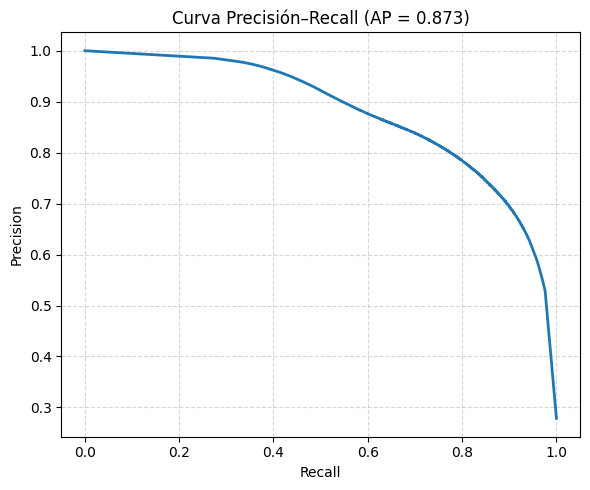

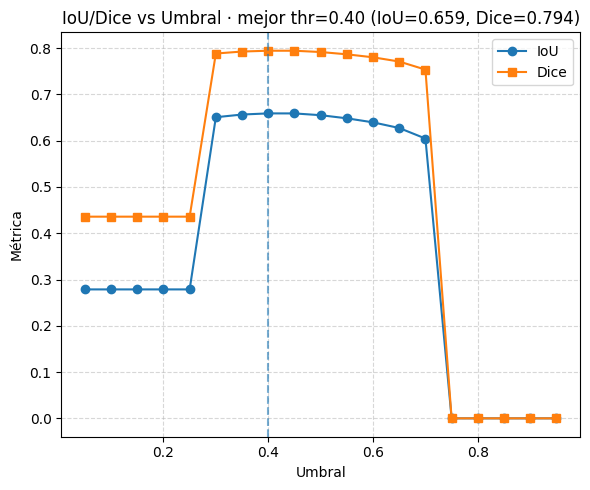

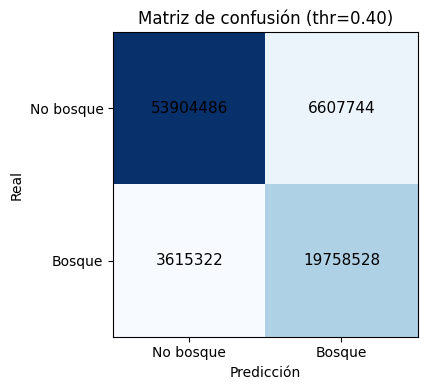

👉 AP=0.873 | Mejor umbral=0.40 | IoU=0.659 | Dice=0.794
👉 Precis./Recall en thr* = P=0.749 | R=0.845


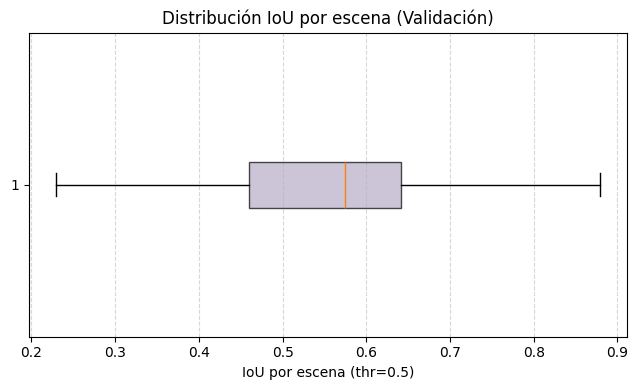

mIoU por escena (thr=0.5): 0.557 ± 0.187
📁 Figuras guardadas en: /content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune/metrics


In [16]:
# ===========================================
#  EVALUACIÓN FINAL · CPU · SIN RE-ENTRENAR
#  (con parche temporal para forzar CPU)
# ===========================================

# 0) Montar Drive (si ya está montado, no pasa nada)
from google.colab import drive
drive.mount('/content/drive')

# 1) Imports base
import os, glob, math, json, numpy as np, matplotlib.pyplot as plt
import torch
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix

device = torch.device("cpu")

# Asegúrate de tener OUT_DIR definido como en tu notebook:
# OUT_DIR = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune"

assert 'OUT_DIR' in globals(), "Falta OUT_DIR en el entorno. Reejecuta la celda de configuración inicial."
assert os.path.isdir(OUT_DIR), f"No existe OUT_DIR: {OUT_DIR}"

# ==========================================================
# 2) Parche temporal de torch.load para forzar map_location='cpu'
# ==========================================================
_real_torch_load = torch.load
def _torch_load_cpu(*args, **kwargs):
    kwargs['map_location'] = 'cpu'
    return _real_torch_load(*args, **kwargs)
torch.load = _torch_load_cpu

# 3) Crear el MODELO con tu misma API (ahora todo carga en CPU)
import satlaspretrain_models as spm
weights_manager = spm.Weights()
model = weights_manager.get_pretrained_model(
    model_identifier="Sentinel2_SwinB_SI_RGB",
    fpn=True, head=spm.Head.SEGMENT, num_categories=2
).to(device).eval()

# (opcional) Restablecer torch.load por si lo quieres normal después
torch.load = _real_torch_load

# 4) Cargar TUS pesos fine-tuned guardados en Drive (CPU-safe de todos modos)
best_path = os.path.join(OUT_DIR, "best_finetuned.pth")
candidates = []
if os.path.exists(best_path): candidates.append(best_path)
candidates += sorted(glob.glob(os.path.join(OUT_DIR, "model_T4_final_epoch*.pth")))
assert candidates, f"No encuentro pesos .pth en {OUT_DIR}"

ckpt_path = candidates[0]
ckpt = torch.load(ckpt_path, map_location='cpu')  # extra seguro
state = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
model.load_state_dict(state, strict=False)
model.eval()
print(f"✅ Modelo restaurado en CPU desde: {ckpt_path}")

# 5) Asegurar val_loader: si no existe, lo reconstruimos simple (1 crop/imagen, sin aug)
from torch.utils.data import DataLoader

if 'val_loader' in globals():
    vloader = val_loader
elif 'val_dl' in globals():
    vloader = val_dl
else:
    assert 'val_pairs' in globals() and 'TILE_SIZE' in globals() and 'SegmentationRandomCrops' in globals(), \
        "Faltan 'val_pairs' / 'TILE_SIZE' / 'SegmentationRandomCrops'. Reejecuta la celda de split y la clase Dataset."
    val_ds_tmp = SegmentationRandomCrops(val_pairs, tile_size=TILE_SIZE, train=False, n_crops_per_image=1)
    vloader = DataLoader(val_ds_tmp, batch_size=1, shuffle=False)

# 6) MÉTRICAS + GRÁFICAS (PR/AP, IoU/Dice vs umbral, confusión, boxplot por escena)
metrics_dir = os.path.join(OUT_DIR, "metrics"); os.makedirs(metrics_dir, exist_ok=True)
all_probs, all_true, iou_por_escena = [], [], []

model.eval()
with torch.no_grad():
    for imgs, gts in vloader:
        imgs = imgs.to(device)              # (B,3,H,W)
        gts  = gts.to(device)               # (B,H,W)

        out = model(imgs)
        if isinstance(out, (tuple, list)): out = out[0]
        if isinstance(out, dict):
            out = out.get('out', out.get('logits',
                   next(v for v in out.values() if torch.is_tensor(v))))

        probs = torch.softmax(out, dim=1)[:, 1]  # clase "bosque"
        pred05 = (probs >= 0.5).long()

        inter = ((pred05==1) & (gts==1)).sum(dim=[1,2]).float()
        union = ((pred05==1) | (gts==1)).sum(dim=[1,2]).float()
        iou_im = torch.where(union>0, inter/union, torch.zeros_like(union))
        iou_por_escena.extend(iou_im.cpu().numpy().tolist())

        all_probs.append(probs.cpu().numpy().ravel())
        all_true.append(gts.cpu().numpy().ravel())

all_probs = np.concatenate(all_probs, axis=0)
all_true  = np.concatenate(all_true,  axis=0).astype(np.uint8)

# (a) PR + AP
prec, rec, thr = precision_recall_curve(all_true, all_probs)
ap = average_precision_score(all_true, all_probs)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, linewidth=2)
plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title(f"Curva Precisión–Recall (AP = {ap:.3f})")
plt.grid(True, ls="--", alpha=.5); plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "curve_PR_AP.png"), dpi=160); plt.show()

# (b) IoU/Dice vs umbral
thresholds = np.linspace(0.05, 0.95, 19)
ious, dices = [], []
for t in thresholds:
    pred = (all_probs >= t).astype(np.uint8)
    tp = np.logical_and(pred==1, all_true==1).sum()
    fp = np.logical_and(pred==1, all_true==0).sum()
    fn = np.logical_and(pred==0, all_true==1).sum()
    inter = tp
    union = np.logical_or(pred==1, all_true==1).sum()
    iou   = inter/union if union>0 else 0.0
    dice  = (2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0.0
    ious.append(iou); dices.append(dice)

best_idx = int(np.argmax(ious))
best_thr = float(thresholds[best_idx])
best_iou = float(ious[best_idx])
best_dice = float(dices[best_idx])

plt.figure(figsize=(6,5))
plt.plot(thresholds, ious, marker="o", label="IoU")
plt.plot(thresholds, dices, marker="s", label="Dice")
plt.axvline(best_thr, ls="--", alpha=.6)
plt.xlabel("Umbral"); plt.ylabel("Métrica")
plt.title(f"IoU/Dice vs Umbral · mejor thr={best_thr:.2f} (IoU={best_iou:.3f}, Dice={best_dice:.3f})")
plt.legend(); plt.grid(True, ls="--", alpha=.5); plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "iou_dice_vs_threshold.png"), dpi=160)
plt.show()

# (c) Matriz de confusión al umbral óptimo
pred_best = (all_probs >= best_thr).astype(np.uint8)
cm = confusion_matrix(all_true, pred_best, labels=[0,1])  # [[TN, FP],[FN, TP]]
TN, FP, FN, TP = cm.ravel()
plt.figure(figsize=(4.5,4))
plt.imshow(cm, cmap="Blues")
plt.xticks([0,1], ["No bosque","Bosque"]); plt.yticks([0,1], ["No bosque","Bosque"])
for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center", fontsize=11)
plt.title(f"Matriz de confusión (thr={best_thr:.2f})")
plt.xlabel("Predicción"); plt.ylabel("Real")
plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "confusion_matrix_best_threshold.png"), dpi=160)
plt.show()

precision_best = TP/(TP+FP) if (TP+FP)>0 else 0.0
recall_best    = TP/(TP+FN) if (TP+FN)>0 else 0.0
print(f"👉 AP={ap:.3f} | Mejor umbral={best_thr:.2f} | IoU={best_iou:.3f} | Dice={best_dice:.3f}")
print(f"👉 Precis./Recall en thr* = P={precision_best:.3f} | R={recall_best:.3f}")

# (d) Boxplot IoU por escena (thr=0.5)
iou_por_escena = np.array(iou_por_escena, dtype=float)
plt.figure(figsize=(6.5,4))
plt.boxplot(iou_por_escena, vert=False, patch_artist=True,
            boxprops=dict(facecolor='#B7ACC6', alpha=.7))
plt.xlabel("IoU por escena (thr=0.5)")
plt.title("Distribución IoU por escena (Validación)")
plt.grid(axis='x', linestyle='--', alpha=.5); plt.tight_layout()
plt.savefig(os.path.join(metrics_dir, "boxplot_iou_por_escena.png"), dpi=160)
plt.show()

print(f"mIoU por escena (thr=0.5): {np.nanmean(iou_por_escena):.3f} ± {np.nanstd(iou_por_escena):.3f}")
print(f"📁 Figuras guardadas en: {metrics_dir}")


In [17]:
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})


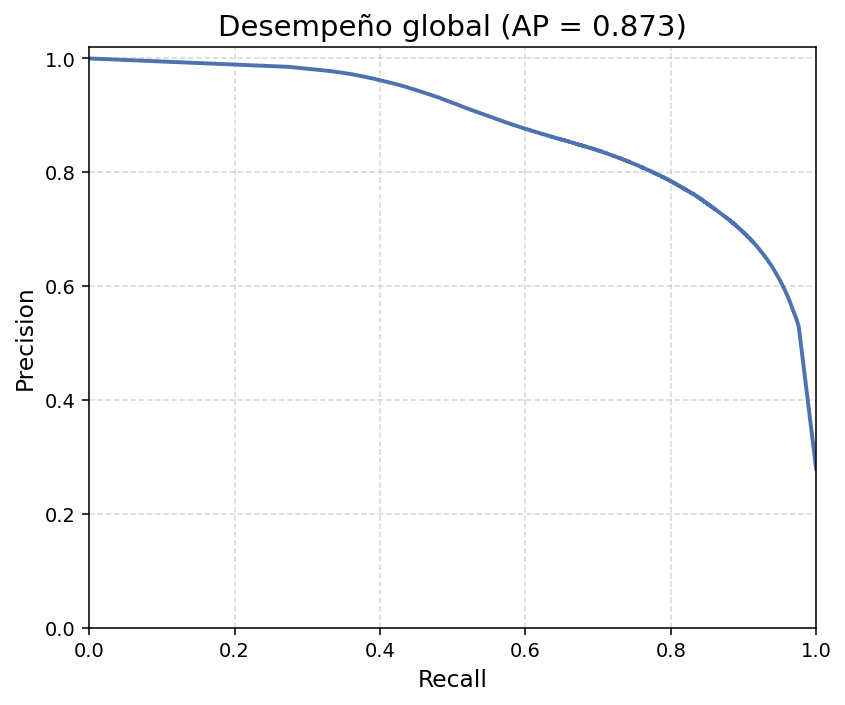

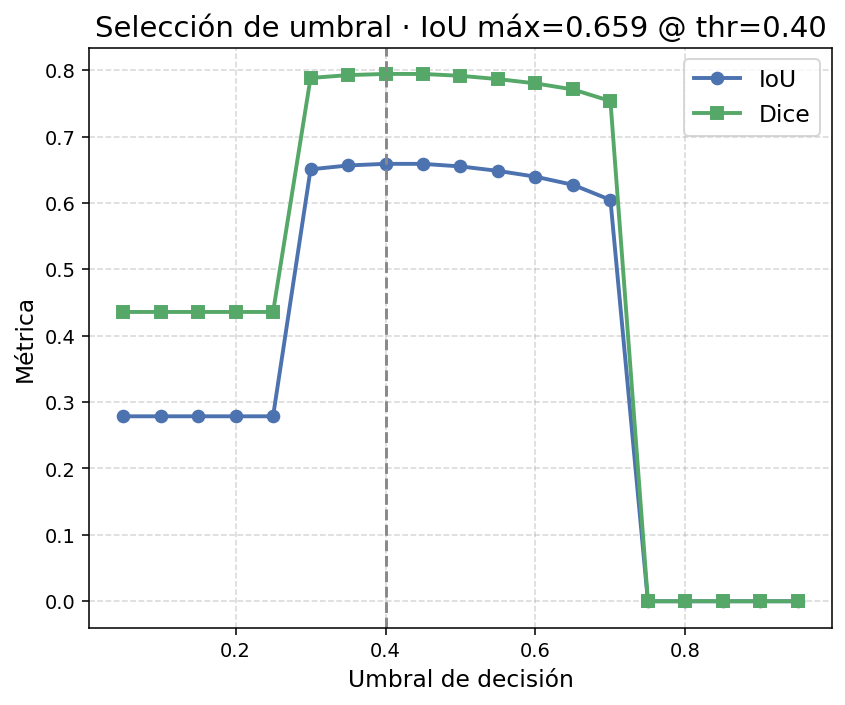

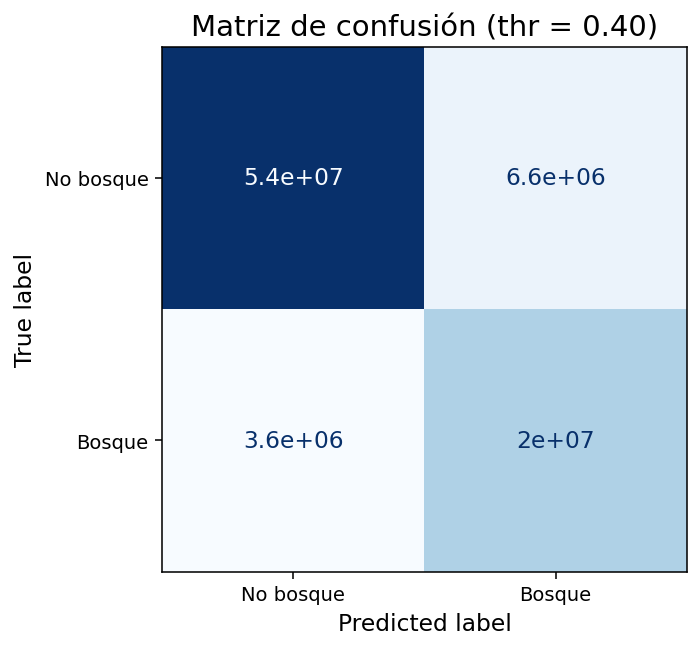

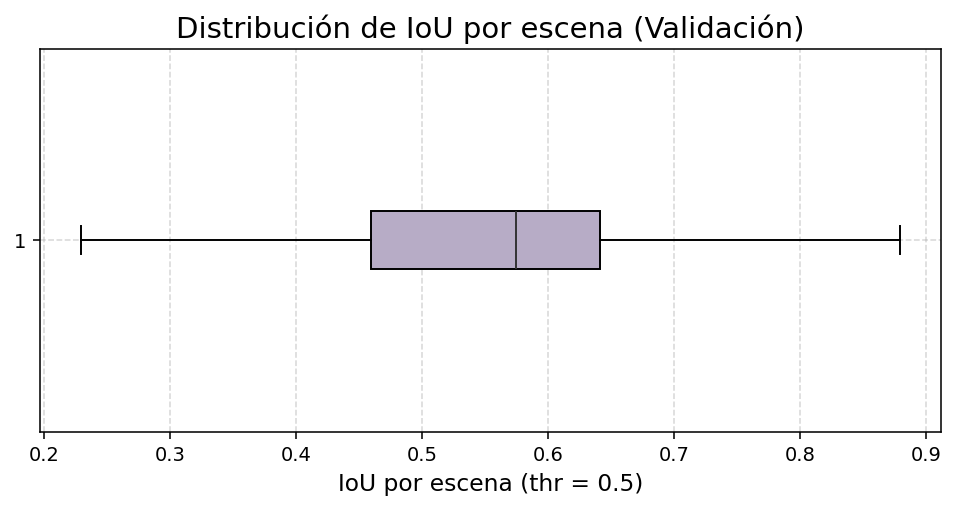

==== RESUMEN PARA SLIDE ====
AP (área bajo PR): 0.873
Umbral óptimo: 0.40 | IoU=0.659 | Dice=0.794
mIoU por escena (thr=0.5): 0.557 ± 0.187
Figuras guardadas en: /content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune/metrics/figs_presentacion


In [18]:
# ============================
#  FIGURAS PARA PONENCIA (solo plotting; sin re-inferencia)
#  Requiere en memoria: all_probs, all_true, iou_por_escena, OUT_DIR
# ============================
import os, numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score, confusion_matrix

# --- checks ---
assert 'OUT_DIR' in globals(), "Falta OUT_DIR (ruta de salida)."
assert 'all_probs' in globals() and 'all_true' in globals(), "Faltan all_probs / all_true (ejecuta la celda de evaluación final una vez)."
assert 'iou_por_escena' in globals(), "Falta iou_por_escena (se genera en la evaluación)."

# --- estilos para presentación ---
plt.rcParams.update({
    "figure.dpi": 140,
    "savefig.dpi": 200,
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "axes.grid": True,
    "grid.alpha": 0.5,
    "grid.linestyle": "--",
})

COLOR1 = "#4C72B0"  # azul principal
COLOR2 = "#55A868"  # verde secundario
GRID  = {"linestyle": "--", "alpha": 0.5}

out_dir = os.path.join(OUT_DIR, "metrics", "figs_presentacion")
os.makedirs(out_dir, exist_ok=True)

# -----------------------------
# 1) Curva Precisión–Recall (AP)
# -----------------------------
prec, rec, _ = precision_recall_curve(all_true, all_probs)
ap = average_precision_score(all_true, all_probs)

plt.figure(figsize=(6.2,5.2))
plt.plot(rec, prec, color=COLOR1, linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Desempeño global (AP = {ap:.3f})")
plt.xlim(0,1); plt.ylim(0,1.02)
plt.grid(**GRID)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "01_curva_PR_AP.png"))
plt.show()

# -----------------------------------
# 2) IoU y Dice vs. Umbral (sweep)
# -----------------------------------
thresholds = np.linspace(0.05, 0.95, 19)
ious, dices = [], []
for t in thresholds:
    pred = (all_probs >= t).astype(np.uint8)
    tp = np.logical_and(pred==1, all_true==1).sum()
    fp = np.logical_and(pred==1, all_true==0).sum()
    fn = np.logical_and(pred==0, all_true==1).sum()
    union = np.logical_or(pred==1, all_true==1).sum()
    iou  = tp/union if union>0 else 0.0
    dice = (2*tp)/(2*tp+fp+fn) if (2*tp+fp+fn)>0 else 0.0
    ious.append(iou); dices.append(dice)

best_idx = int(np.argmax(ious))
best_thr = float(thresholds[best_idx])
best_iou = float(ious[best_idx])
best_dice= float(dices[best_idx])

plt.figure(figsize=(6.2,5.2))
plt.plot(thresholds, ious,  marker="o", color=COLOR1, label="IoU",  linewidth=2)
plt.plot(thresholds, dices, marker="s", color=COLOR2, label="Dice", linewidth=2)
plt.axvline(best_thr, color="#888888", linestyle="--")
plt.xlabel("Umbral de decisión")
plt.ylabel("Métrica")
plt.title(f"Selección de umbral · IoU máx={best_iou:.3f} @ thr={best_thr:.2f}")
plt.legend()
plt.grid(**GRID)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "02_iou_dice_vs_umbral.png"))
plt.show()

# -----------------------------------
# 3) Matriz de confusión (umbral óptimo)
# -----------------------------------
from sklearn.metrics import ConfusionMatrixDisplay
pred_best = (all_probs >= best_thr).astype(np.uint8)
cm = confusion_matrix(all_true, pred_best, labels=[0,1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No bosque","Bosque"])

fig, ax = plt.subplots(figsize=(5.2,4.8))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matriz de confusión (thr = {best_thr:.2f})")
ax.grid(False)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "03_matriz_confusion_thr_optimo.png"))
plt.show()

# ------------------------------------------------
# 4) Boxplot IoU por escena (consistencia espacial)
# ------------------------------------------------
iou_arr = np.array(iou_por_escena, dtype=float)
plt.figure(figsize=(7.0,3.8))
bp = plt.boxplot(iou_arr, vert=False, patch_artist=True)
for patch in bp['boxes']: patch.set_facecolor("#B7ACC6")
for med in bp['medians']: med.set_color("#333333")
plt.xlabel("IoU por escena (thr = 0.5)")
plt.title("Distribución de IoU por escena (Validación)")
plt.grid(axis="x", **GRID)
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "04_boxplot_iou_por_escena.png"))
plt.show()

# ---- Resumen impreso (para tu slide) ----
print("==== RESUMEN PARA SLIDE ====")
print(f"AP (área bajo PR): {ap:.3f}")
print(f"Umbral óptimo: {best_thr:.2f} | IoU={best_iou:.3f} | Dice={best_dice:.3f}")
print(f"mIoU por escena (thr=0.5): {np.nanmean(iou_arr):.3f} ± {np.nanstd(iou_arr):.3f}")
print(f"Figuras guardadas en: {out_dir}")


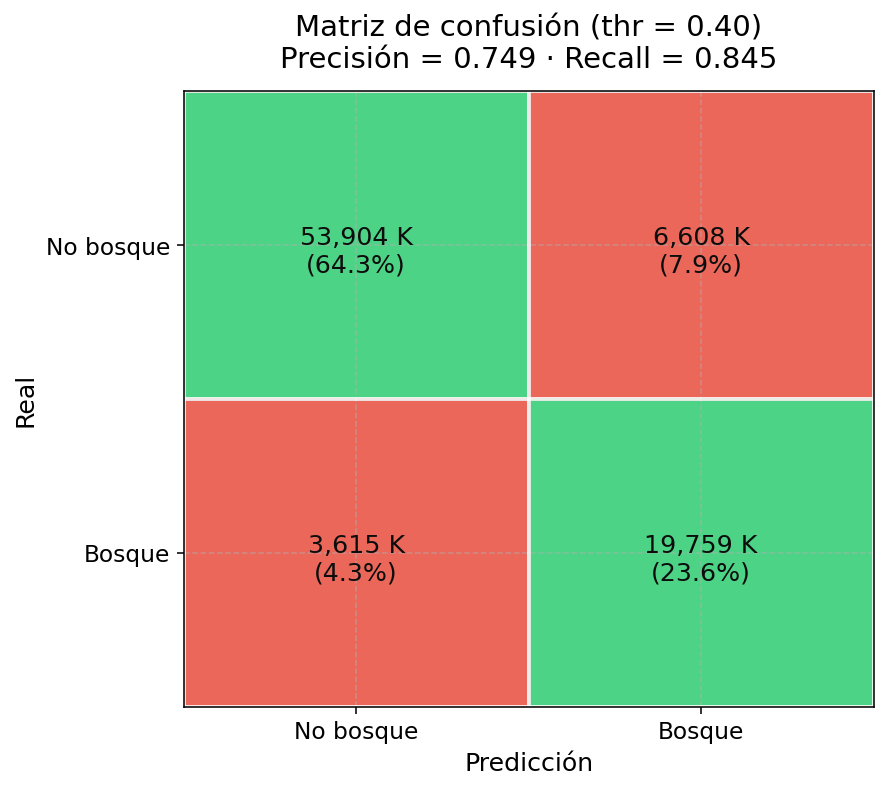

In [19]:
# ========== MATRIZ DE CONFUSIÓN (verde/rojo, números en miles + %) ==========
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

assert 'all_probs' in globals() and 'all_true' in globals(), "Faltan all_probs/all_true (ejecuta evaluación una vez)."

# Umbral a usar (si no existe best_thr, usamos 0.5)
thr = float(best_thr) if 'best_thr' in globals() else 0.5

# Predicción binaria
pred = (all_probs >= thr).astype(np.uint8)

# Matriz de confusión con orden [0,1] = [No bosque, Bosque]
cm = confusion_matrix(all_true, pred, labels=[0,1]).astype(np.float64)
TN, FP, FN, TP = cm.ravel()
total = cm.sum()

# Normalización a porcentaje
cm_pct = 100.0 * cm / total

# Números en "miles" (K)
cm_k = cm / 1000.0

# ---- Plot manual con colores verde (aciertos) / rojo (errores) ----
fig, ax = plt.subplots(figsize=(6.5, 5.8))
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.invert_yaxis()  # para que [0,0] quede arriba-izquierda

# Dibujar rectángulos por celda con color según acierto/error
for i in range(2):           # filas = etiqueta real
    for j in range(2):       # columnas = predicción
        is_correct = (i == j)
        # Colores: verde para diagonal, rojo para off-diagonal
        face = "#2ECC71" if is_correct else "#E74C3C"  # verde / rojo
        edge = "#1B5E20" if is_correct else "#7F1D1D"  # bordes más oscuros
        rect = plt.Rectangle((j, i), 1, 1, facecolor=face, edgecolor=edge, linewidth=1.5, alpha=0.85)
        ax.add_patch(rect)

        # Texto: "xxxx K (yy%)"
        txt = f"{cm_k[i,j]:,.0f} K\n({cm_pct[i,j]:.1f}%)"
        ax.text(j+0.5, i+0.52, txt, ha="center", va="center", fontsize=13, color="#0D0D0D")

# Ejes y títulos
ax.set_xticks([0.5, 1.5]); ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["No bosque", "Bosque"], fontsize=12)
ax.set_yticklabels(["No bosque", "Bosque"], fontsize=12)
ax.set_xlabel("Predicción", fontsize=13)
ax.set_ylabel("Real", fontsize=13)
ax.set_title(f"Matriz de confusión (thr = {thr:.2f})\n"
             f"Precisión = {TP/(TP+FP):.3f} · Recall = {TP/(TP+FN):.3f}", fontsize=15, pad=12)

# Líneas de cuadrícula de las celdas
for x in [0,1,2]:
    ax.axvline(x, color="white", linewidth=2, alpha=0.9)
    ax.axhline(x, color="white", linewidth=2, alpha=0.9)

plt.tight_layout()
plt.show()


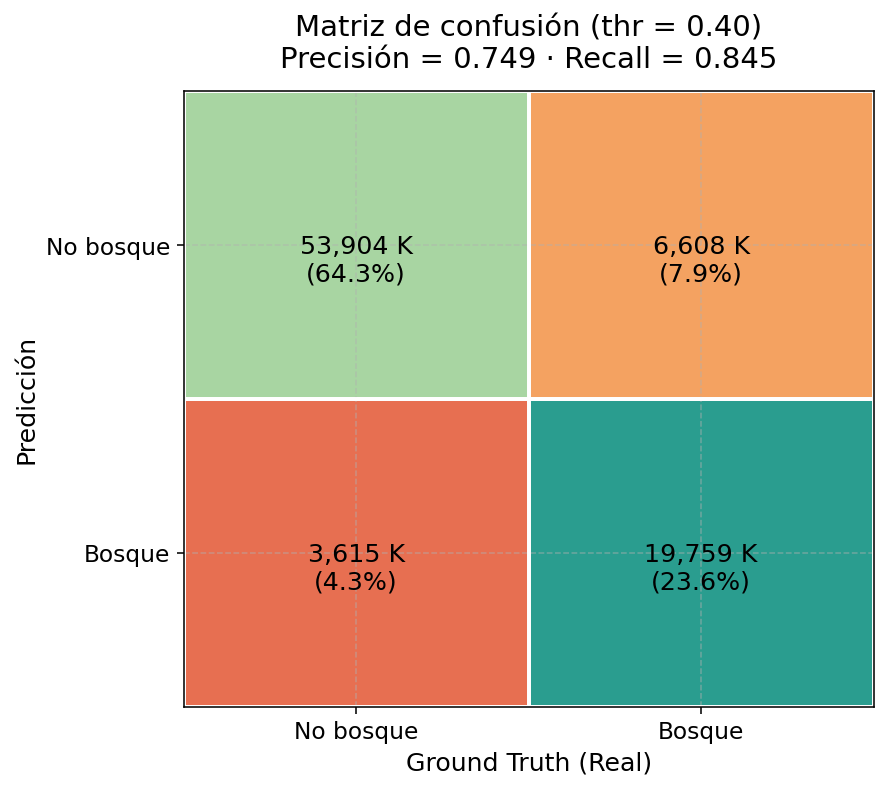

In [20]:
# ===== MATRIZ DE CONFUSIÓN (colores estilo clásico: verde/naranja) =====
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

assert 'all_probs' in globals() and 'all_true' in globals(), "Faltan all_probs/all_true (ejecuta evaluación una vez)."

# Umbral (si no existe best_thr, usa 0.5)
thr = float(best_thr) if 'best_thr' in globals() else 0.5

# Predicción binaria
pred = (all_probs >= thr).astype(np.uint8)

# Matriz de confusión con orden [0,1] = [No bosque, Bosque]
cm = confusion_matrix(all_true, pred, labels=[0,1]).astype(np.float64)
TN, FP, FN, TP = cm.ravel()
total = cm.sum()

# Porcentajes y valores en miles
cm_pct = 100.0 * cm / total
cm_k = cm / 1000.0

# ---- Colores estilo referencia ----
colors = np.array([
    ["#A8D5A2", "#F4A261"],  # fila 0: Pred. No bosque (TN verde, FP naranja)
    ["#E76F51", "#2A9D8F"]   # fila 1: Pred. Bosque (FN rojo, TP verde-azulado)
])

# ---- Plot ----
fig, ax = plt.subplots(figsize=(6.5, 5.8))
ax.set_xlim(0, 2)
ax.set_ylim(0, 2)
ax.invert_yaxis()

for i in range(2):  # filas = predicciones
    for j in range(2):  # columnas = verdad
        rect = plt.Rectangle((j, i), 1, 1,
                             facecolor=colors[i, j],
                             edgecolor="white", linewidth=2)
        ax.add_patch(rect)
        txt = f"{cm_k[i,j]:,.0f} K\n({cm_pct[i,j]:.1f}%)"
        ax.text(j+0.5, i+0.55, txt, ha="center", va="center", fontsize=13, color="black")

# Etiquetas de ejes
ax.set_xticks([0.5, 1.5])
ax.set_yticks([0.5, 1.5])
ax.set_xticklabels(["No bosque", "Bosque"], fontsize=12)
ax.set_yticklabels(["No bosque", "Bosque"], fontsize=12)
ax.set_xlabel("Ground Truth (Real)", fontsize=13)
ax.set_ylabel("Predicción", fontsize=13)
ax.set_title(f"Matriz de confusión (thr = {thr:.2f})\n"
             f"Precisión = {TP/(TP+FP):.3f} · Recall = {TP/(TP+FN):.3f}",
             fontsize=15, pad=12)

# Líneas blancas para el marco
for x in [0, 1, 2]:
    ax.axvline(x, color="white", linewidth=2)
    ax.axhline(x, color="white", linewidth=2)

plt.tight_layout()
plt.show()


8) Evaluación por escena (tiles → agregación) y reporte rápido

ID=1050  IoU=0.723
ID=1051  IoU=0.229
ID=1109  IoU=0.567
ID=1251  IoU=0.484
ID=1301  IoU=0.581
ID=1371  IoU=0.387
ID=1001  IoU=0.881
ID=1086  IoU=0.604


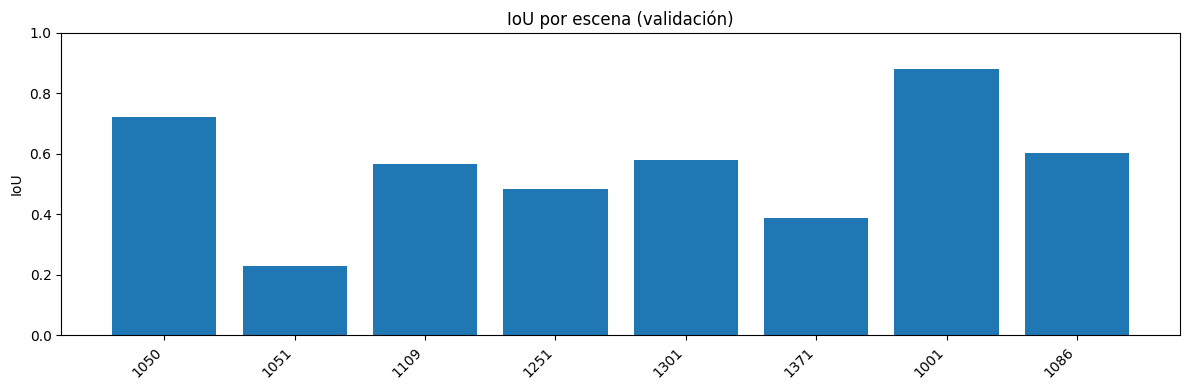

In [13]:
# ====== EVALUACION POR ESCENA (VAL) ======
@torch.no_grad()
def eval_scene(img_path, label_path, tile=TILE_SIZE, stride=None):
    """
    Evalúa IoU a nivel de escena con ventanas deslizantes.
    """
    stride = stride or tile
    rgb, transform, crs = read_rgb_bgrn_as_rgb(img_path, perc_rescale=True)
    _, H, W = rgb.shape
    gt = rasterize_geojson_to_match(label_path, H, W, transform, crs)
    gt_t = torch.from_numpy(gt).long().to(device)

    prob = torch.zeros((H, W), device=device)
    cnt  = torch.zeros((H, W), device=device)

    for y in range(0, H, stride):
        for x in range(0, W, stride):
            tile_rgb = rgb[:, y:y+tile, x:x+tile]
            ph, pw = tile_rgb.shape[1:]
            if ph < tile or pw < tile:
                # pad reflect
                pad_h = tile - ph; pad_w = tile - pw
                tile_rgb = np.pad(tile_rgb, ((0,0),(0,pad_h),(0,pad_w)), mode='reflect')

            t = torch.from_numpy(tile_rgb).float().unsqueeze(0).to(device)
            out = model(t)
            if isinstance(out,(tuple,list)): out = out[0]
            if isinstance(out,dict):
                out = out.get('out', out.get('logits',
                       next(v for v in out.values() if torch.is_tensor(v))))
            p = torch.softmax(out, dim=1)[0,1]  # (tile,tile)
            p = p[:ph, :pw]

            prob[y:y+ph, x:x+pw] += p
            cnt [y:y+ph, x:x+pw] += 1

    prob = prob / torch.clamp(cnt, min=1)
    pred = (prob >= 0.5).long()

    inter = ((pred==1) & (gt_t==1)).sum().item()
    union = ((pred==1) | (gt_t==1)).sum().item()
    iou = float('nan') if union==0 else inter/union
    return iou

# Cargar el mejor modelo
best_path = os.path.join(OUT_DIR, "best_finetuned.pth")
model.load_state_dict(torch.load(best_path, map_location=device))
model.eval()

scene_ious = []
for ip, lp, iid in val_pairs:
    iou = eval_scene(ip, lp, tile=TILE_SIZE, stride=TILE_SIZE)
    scene_ious.append((iid, iou))
    print(f"ID={iid}  IoU={iou:.3f}")

# Gráfica resumen
ids = [s[0] for s in scene_ious]
vals = [s[1] for s in scene_ious]
plt.figure(figsize=(12,4))
plt.bar(range(len(ids)), [0 if (v is None or np.isnan(v)) else v for v in vals])
plt.xticks(range(len(ids)), ids, rotation=45, ha='right')
plt.ylim(0,1); plt.ylabel("IoU"); plt.title("IoU por escena (validación)"); plt.tight_layout(); plt.show()


# 5. PROBAR EL MODELO HECHO

In [21]:
# ===============================================
# Batch: NDVI -> inferencia selectiva -> guardado -> PLOTEO GLOBAL (FINE-TUNED)
# CPU-SEGURO + RUTAS T4 + THR ÓPTIMO
# ===============================================

import os, glob, numpy as np, torch, rasterio, matplotlib.pyplot as plt
import satlaspretrain_models as spm

# --- Rutas base (T4) ---
BASE_DIR   = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune"
FT_WEIGHTS = os.path.join(BASE_DIR, "best_finetuned.pth")   # pesos fine-tuned
DATA_DIR   = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/image"
OUT_ROOT   = os.path.join(BASE_DIR, "outputs_pred")
os.makedirs(OUT_ROOT, exist_ok=True)

# --- Config ---
NDVI_THR      = 0.19
PROB_THR      = float(best_thr) if 'best_thr' in globals() else 0.40  # usa el óptimo si existe
PERC_RESCALE  = True
TILE, STRIDE  = 1024, 1024       # si ves “costuras”, prueba STRIDE=512
NDVI_VMIN, NDVI_VMAX = -0.2, 0.8

# Buscar GeoTIFFs
tif_list = sorted(glob.glob(os.path.join(DATA_DIR, "*.tif")) + glob.glob(os.path.join(DATA_DIR, "*.tiff")))
assert len(tif_list) > 0, f"No se encontraron .tif/.tiff en {DATA_DIR}"

# --- Modelo (CPU-seguro): parcheamos torch.load para evitar CUDA dentro de spm ---
device = torch.device("cpu")
_real_torch_load = torch.load
def _torch_load_cpu(*args, **kwargs):
    kwargs["map_location"] = "cpu"
    return _real_torch_load(*args, **kwargs)
torch.load = _torch_load_cpu

weights_manager = spm.Weights()
model = weights_manager.get_pretrained_model(
    model_identifier="Sentinel2_SwinB_SI_RGB",
    fpn=True, head=spm.Head.SEGMENT, num_categories=2
).to(device).eval()

# restauramos torch.load normal (por si lo necesitas después)
torch.load = _real_torch_load

# Cargar pesos fine-tuned (forzando CPU por seguridad)
ckpt_ft = torch.load(FT_WEIGHTS, map_location="cpu")
state = ckpt_ft.get("model", ckpt_ft)  # soporta dict {'model': state_dict} o state_dict directo
model.load_state_dict(state, strict=False)
model.eval()

def infer_prob_tiled_selective(rgb_img, cand_mask):
    """Devuelve prob(bosque) haciendo inferencia solo donde NDVI marca candidato."""
    H_, W_, _ = rgb_img.shape
    prob = np.zeros((H_, W_), dtype=np.float32)
    for y in range(0, H_, STRIDE):
        for x in range(0, W_, STRIDE):
            cand_tile = cand_mask[y:y+TILE, x:x+TILE]
            if cand_tile.size == 0 or not cand_tile.any():
                continue
            tile = rgb_img[y:y+TILE, x:x+TILE, :]
            ph, pw = tile.shape[:2]
            pad = (ph < TILE) or (pw < TILE)
            if pad:
                tile = np.pad(tile, ((0, TILE-ph), (0, TILE-pw), (0, 0)), mode="reflect")

            t = torch.from_numpy(tile.transpose(2,0,1)).unsqueeze(0).to(device).float()
            with torch.no_grad():
                out = model(t)
                if isinstance(out, (tuple, list)): out = out[0]
                if isinstance(out, dict):
                    out = out.get('out', out.get('logits',
                           next(v for v in out.values() if torch.is_tensor(v))))
                p = torch.softmax(out, dim=1)[0, 1].cpu().numpy()

            if pad:
                p = p[:ph, :pw]
            p_mask = cand_tile[:ph, :pw]
            prob[y:y+ph, x:x+pw][p_mask] = p[p_mask]
    return prob

processed = []

for img_path in tif_list:
    name = os.path.splitext(os.path.basename(img_path))[0]
    out_dir = os.path.join(OUT_ROOT, name)
    os.makedirs(out_dir, exist_ok=True)
    print(f"\n▶ Procesando: {name}")

    # --- Lectura bandas ---
    with rasterio.open(img_path) as src:
        count = src.count
        if count < 4:
            print(f"  ⚠ Saltado: se requieren B2,B3,B4,B8 (>=4 bandas). Bandas={count}")
            continue
        B2, B3, B4, B8 = src.read([1,2,3,4]).astype(np.float32)
        transform, crs = src.transform, src.crs

    # --- Escalado a 0-1 robusto ---
    mx = float(max(B2.max(), B3.max(), B4.max(), B8.max()))
    scale = 10000.0 if mx > 5000 else (255.0 if mx > 1.5 else 1.0)
    B2, B3, B4, B8 = B2/scale, B3/scale, B4/scale, B8/scale

    # --- NDVI y candidatos ---
    ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
    ndvi = np.clip(ndvi, -1, 1)
    cand = (ndvi >= NDVI_THR)

    # --- RGB para el modelo (B4,B3,B2) ---
    rgb_arr = np.stack([B4, B3, B2], axis=0)
    if PERC_RESCALE:
        arr = rgb_arr.copy()
        for c in range(3):
            p2, p98 = np.percentile(arr[c], [2, 98])
            if p98 > p2:
                arr[c] = np.clip((arr[c]-p2)/(p98-p2), 0, 1)
        rgb_arr = arr
    rgb = np.transpose(rgb_arr, (1, 2, 0))
    H, W, _ = rgb.shape

    # --- Inferencia selectiva ---
    prob = infer_prob_tiled_selective(rgb, cand)
    mask = (cand & (prob >= PROB_THR)).astype(np.uint8)

    # --- Guardados GeoTIFFs ---
    ndvi_tif = os.path.join(out_dir, f"{name}_ndvi_float32.tif")
    with rasterio.open(ndvi_tif, "w", driver="GTiff", height=H, width=W, count=1,
                       dtype=rasterio.float32, crs=crs, transform=transform, compress="LZW") as dst:
        dst.write(ndvi.astype(np.float32), 1)

    prob_tif = os.path.join(out_dir, f"{name}_prob_selective.tif")
    with rasterio.open(prob_tif, "w", driver="GTiff", height=H, width=W, count=1,
                       dtype=rasterio.float32, crs=crs, transform=transform, compress="LZW") as dst:
        dst.write(prob.astype(np.float32), 1)

    mask_tif = os.path.join(out_dir, f"{name}_mask_ndvi{NDVI_THR:.2f}_prob{PROB_THR:.2f}.tif")
    with rasterio.open(mask_tif, "w", driver="GTiff", height=H, width=W, count=1,
                       dtype=rasterio.uint8, crs=crs, transform=transform, compress="LZW") as dst:
        dst.write(mask, 1)

    # --- Preview individual PNG ---
    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    ax[0].imshow(rgb); ax[0].set_title("RGB"); ax[0].axis("off")
    im1 = ax[1].imshow(ndvi, vmin=NDVI_VMIN, vmax=NDVI_VMAX, cmap="RdYlGn")
    ax[1].contour(cand, levels=[0.5], colors='k', linewidths=0.7); ax[1].set_title(f"NDVI (≥{NDVI_THR})"); ax[1].axis("off")
    plt.colorbar(im1, ax=ax[1], fraction=0.046, pad=0.04)
    overlay = rgb.copy()
    overlay[mask == 1] = [1, 0, 0]
    ax[2].imshow(0.6*rgb + 0.4*overlay); ax[2].set_title(f"Bosque = NDVI≥{NDVI_THR} ∧ Prob≥{PROB_THR}")
    ax[2].axis("off")
    fig.tight_layout()
    preview_png = os.path.join(out_dir, f"{name}_preview.png")
    fig.savefig(preview_png, dpi=150)
    plt.close(fig)

    processed.append({"name": name, "src_path": img_path, "ndvi_tif": ndvi_tif, "prob_tif": prob_tif, "mask_tif": mask_tif})
    print(f"  ✔ Guardado en {out_dir}")

# =============================
# PLOTEO GLOBAL (todas las filas)
# =============================
if len(processed) > 0:
    n = len(processed)
    fig, axes = plt.subplots(n, 3, figsize=(18, 6*n))
    if n == 1: axes = np.expand_dims(axes, axis=0)

    for i, rec in enumerate(processed):
        name = rec["name"]
        with rasterio.open(rec["src_path"]) as src:
            B2, B3, B4 = src.read([1,2,3]).astype(np.float32)
            mx = float(max(B2.max(), B3.max(), B4.max()))
            scale = 10000.0 if mx > 5000 else (255.0 if mx > 1.5 else 1.0)
            B2, B3, B4 = B2/scale, B3/scale, B4/scale
            rgb_arr = np.stack([B4, B3, B2], axis=0)
            if PERC_RESCALE:
                arr = rgb_arr.copy()
                for c in range(3):
                    p2, p98 = np.percentile(arr[c], [2, 98])
                    if p98 > p2: arr[c] = np.clip((arr[c]-p2)/(p98-p2), 0, 1)
                rgb_arr = arr
            rgb = np.transpose(rgb_arr, (1, 2, 0))

        with rasterio.open(rec["ndvi_tif"]) as src: ndvi = src.read(1)
        with rasterio.open(rec["mask_tif"]) as src: mask = src.read(1)

        axes[i,0].imshow(rgb); axes[i,0].set_title(f"{name} - RGB"); axes[i,0].axis("off")
        im1 = axes[i,1].imshow(ndvi, vmin=NDVI_VMIN, vmax=NDVI_VMAX, cmap="RdYlGn")
        axes[i,1].set_title("NDVI"); axes[i,1].axis("off"); fig.colorbar(im1, ax=axes[i,1], fraction=0.046, pad=0.04)
        overlay = rgb.copy(); overlay[mask==1] = [1,0,0]
        axes[i,2].imshow(0.6*rgb + 0.4*overlay); axes[i,2].set_title(f"Bosque final (NDVI≥{NDVI_THR} ∧ Prob≥{PROB_THR})"); axes[i,2].axis("off")

    fig.tight_layout(); plt.show()
else:
    print("No hubo imágenes procesadas.")


Output hidden; open in https://colab.research.google.com to view.

In [22]:
# ===============================================
# IoU por imagen (clase única) + Tripletas + Gráfica resumen (FINE-TUNED) · T4
# ===============================================
import os, re, glob, csv
import numpy as np
import rasterio
from rasterio.features import rasterize
import geopandas as gpd
import matplotlib.pyplot as plt

# --- Rutas T4 ---
BASE_DIR   = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune"
DST        = os.path.join(BASE_DIR, "outputs_pred")        # donde guardaste las predicciones del bloque anterior
LABELS_DIR = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/labels"
IMG_DIR    = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/image"

def extract_id_from_name(name):
    m = re.search(r'id[_\-]?(\d+)', name, re.IGNORECASE)
    if m: return str(int(m.group(1)))
    m2 = re.search(r'(\d+)', name)
    return str(int(m2.group(1))) if m2 else None

def find_original_image(img_dir, the_id):
    cands = glob.glob(os.path.join(img_dir, "*.tif")) + glob.glob(os.path.join(img_dir, "*.tiff"))
    the_id_norm = str(int(the_id))
    for p in cands:
        base = os.path.basename(p)
        if re.search(rf'(^|[^0-9]){the_id_norm}([^0-9]|$)', base):
            return p
    return None

def read_rgb_from_tif(tif_path, perc_rescale=True):
    with rasterio.open(tif_path) as src:
        # B4,B3,B2 para componer RGB "natural"
        B2, B3, B4 = src.read([1,2,3]).astype(np.float32)
        mx = max(float(B2.max()), float(B3.max()), float(B4.max()))
        scale = 10000.0 if mx > 5000 else (255.0 if mx > 1.5 else 1.0)
        B2, B3, B4 = B2/scale, B3/scale, B4/scale
        rgb_arr = np.stack([B4, B3, B2], axis=0)
        if perc_rescale:
            arr = rgb_arr.copy()
            for c in range(3):
                p2, p98 = np.percentile(arr[c], [2, 98])
                if p98 > p2:
                    arr[c] = np.clip((arr[c]-p2)/(p98-p2), 0, 1)
            rgb_arr = arr
        rgb = np.transpose(rgb_arr, (1,2,0))
    return rgb

def rasterize_geojson_to_match(geojson_path, ref_profile):
    gdf = gpd.read_file(geojson_path)
    if gdf.empty:
        return np.zeros((ref_profile['height'], ref_profile['width']), dtype=np.uint8)
    crs_dst = ref_profile['crs']
    gdf_aligned = gdf if (gdf.crs is None or str(gdf.crs) == str(crs_dst)) else gdf.to_crs(crs_dst)
    shapes = [(geom, 1) for geom in gdf_aligned.geometry if geom is not None and not geom.is_empty]
    if len(shapes) == 0:
        return np.zeros((ref_profile['height'], ref_profile['width']), dtype=np.uint8)
    return rasterize(
        shapes=shapes,
        out_shape=(ref_profile['height'], ref_profile['width']),
        transform=ref_profile['transform'],
        fill=0, dtype='uint8',
        all_touched=False
    )

def compute_iou(pred_mask, gt_mask):
    pred_bin = (pred_mask == 1); gt_bin = (gt_mask == 1)
    inter = np.logical_and(pred_bin, gt_bin).sum()
    union = np.logical_or(pred_bin, gt_bin).sum()
    return np.nan if union == 0 else inter / union

# --- Recorrer carpetas de predicción (una por imagen) ---
folders = sorted([f for f in glob.glob(os.path.join(DST, "*")) if os.path.isdir(f)])
results = []

for out_dir in folders:
    base = os.path.basename(out_dir)
    the_id = extract_id_from_name(base)
    if the_id is None:
        print(f"⚠ No se encontró id en {base}, saltando.")
        continue

    mask_tifs = glob.glob(os.path.join(out_dir, "*_mask_ndvi*.tif"))
    if len(mask_tifs) == 0:
        print(f"⚠ No encontré mask en {out_dir}, saltando.")
        continue
    mask_path = mask_tifs[0]

    label_path = os.path.join(LABELS_DIR, f"label_{the_id}.geojson")
    if not os.path.exists(label_path):
        print(f"⚠ No encontré label para id={the_id}: {label_path}")
        continue

    # leer máscara predicha y definir profile de referencia
    with rasterio.open(mask_path) as srcm:
        pred_mask = srcm.read(1)
        if srcm.nodata is not None:
            pred_mask = np.where(pred_mask == srcm.nodata, 0, pred_mask).astype(np.uint8)
        else:
            pred_mask = pred_mask.astype(np.uint8)
        ref_profile = srcm.profile

    # rasterizar geojson al grid de la predicción
    gt_mask = rasterize_geojson_to_match(label_path, ref_profile)
    iou = compute_iou(pred_mask, gt_mask)
    img_path = find_original_image(IMG_DIR, the_id)

    results.append({
        "id": the_id,
        "out_dir": out_dir,
        "mask_path": mask_path,
        "label_path": label_path,
        "img_path": img_path,
        "iou": iou
    })

# --- Ploteo comparativo (RGB + GT + Pred) ---
if len(results) == 0:
    print("No hay pares predicción/label para plotear.")
else:
    n = len(results)
    fig, axes = plt.subplots(n, 3, figsize=(18, 6*n))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, rec in enumerate(results):
        the_id, mask_path, label_path, img_path, iou = rec["id"], rec["mask_path"], rec["label_path"], rec["img_path"], rec["iou"]

        with rasterio.open(mask_path) as srcm:
            pred_mask = srcm.read(1).astype(np.uint8)
            if srcm.nodata is not None:
                pred_mask = np.where(pred_mask == srcm.nodata, 0, pred_mask).astype(np.uint8)
            ref_profile = srcm.profile
        gt_mask = rasterize_geojson_to_match(label_path, ref_profile)

        if img_path and os.path.exists(img_path):
            try:
                rgb = read_rgb_from_tif(img_path, perc_rescale=True)
            except Exception as e:
                print(f"⚠ RGB {img_path}: {e}")
                rgb = np.dstack([pred_mask]*3).astype(np.float32)
        else:
            rgb = np.dstack([pred_mask]*3).astype(np.float32)

        axes[i,0].imshow(rgb); axes[i,0].set_title(f"ID {the_id} - RGB"); axes[i,0].axis("off")
        axes[i,1].imshow(rgb)
        gt_overlay = np.zeros((*gt_mask.shape, 4), dtype=np.float32); gt_overlay[gt_mask==1] = [0, 1, 0, 0.45]
        axes[i,1].imshow(gt_overlay); axes[i,1].set_title("Máscara real"); axes[i,1].axis("off")
        axes[i,2].imshow(rgb)
        pred_overlay = np.zeros((*pred_mask.shape, 4), dtype=np.float32); pred_overlay[pred_mask==1] = [1, 0, 0, 0.45]
        axes[i,2].imshow(pred_overlay)
        t_iou = "IoU: NaN" if (iou is None or np.isnan(iou)) else f"IoU: {100*iou:.2f}%"
        axes[i,2].set_title(f"Predicción · {t_iou}"); axes[i,2].axis("off")

    fig.tight_layout()
    out_png = os.path.join(DST, "resumen_tripletas_iou_finetuned.png")
    fig.savefig(out_png, dpi=150); plt.show()
    print(f"🖼️ Guardado ploteo global: {out_png}")

# --- Gráfica IoU + CSV + resumen en consola ---
if len(results) > 0:
    ids  = [r["id"] for r in results]
    ious = [r["iou"] for r in results]
    ious_clean = [v for v in ious if (v is not None and not np.isnan(v))]
    mean_iou = float(np.mean(ious_clean)) if ious_clean else float("nan")
    std_iou  = float(np.std(ious_clean))  if ious_clean else float("nan")

    print(f"✅ IoU medio = {mean_iou:.3f}  ·  std = {std_iou:.3f}  ·  imágenes evaluadas = {len(ious_clean)}/{len(ious)}")

    fig2, ax2 = plt.subplots(figsize=(14, 5))
    x = np.arange(len(ids))
    ax2.bar(x, [0 if (v is None or np.isnan(v)) else v for v in ious], color="#4C72B0")
    ax2.axhline(mean_iou, color="#55A868", linestyle="--", linewidth=2, label=f"Media IoU = {mean_iou:.3f}")
    ax2.set_xticks(x); ax2.set_xticklabels(ids, rotation=45, ha='right')
    ax2.set_ylim(0,1); ax2.set_ylabel("IoU"); ax2.set_title("IoU por imagen (fine-tuned)")
    ax2.legend(loc="upper right")
    fig2.tight_layout()
    out_png2 = os.path.join(DST, "iou_por_id_finetuned.png")
    fig2.savefig(out_png2, dpi=150); plt.show()
    print(f"📊 Guardado gráfico IoU: {out_png2}")

    out_csv = os.path.join(DST, "iou_por_id_finetuned.csv")
    with open(out_csv, "w", newline="") as f:
        w = csv.writer(f); w.writerow(["id", "iou"])
        for r in results:
            v = "" if (r["iou"] is None or np.isnan(r["iou"])) else r["iou"]
            w.writerow([r["id"], v])
    print(f"🧾 Guardado CSV IoU: {out_csv}")


Output hidden; open in https://colab.research.google.com to view.

#7. INFERENCIA TOTAL CUNDINAMARCA

1) Configuración + carga del modelo fine-tuned

In [23]:
# ====== CONFIG + MODELO (T4 · CPU-safe) ======
import os, math, numpy as np, torch, rasterio
from rasterio.windows import Window
import satlaspretrain_models as spm

# --- Rutas (T4) ---
BIG_IMG   = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/Sentinel_RGBNIR_2025_CAR.tif"
BASE_OUT  = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data"
TILES_OUT = os.path.join(BASE_OUT, "pred_tiles_512")            # carpeta con .tif por tile
FULL_OUT  = os.path.join(BASE_OUT, "pred_full_merged.tif")
WEIGHTS   = "/content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/finetune/best_finetuned.pth"

os.makedirs(TILES_OUT, exist_ok=True)

# --- Parámetros de inferencia ---
TILE, STRIDE = 512, 512
NDVI_THR     = 0.19
# Usa el mejor umbral calculado; si no existe en memoria, queda 0.40
PROB_THR     = float(best_thr) if 'best_thr' in globals() else 0.40
PERC_RESCALE = True  # reescala percentiles 2-98 para entrada del modelo

device = torch.device("cpu")  # forzamos CPU

# --- Carga arquitectura y pesos fine-tuned (CPU-safe) ---
# Parche temporal para evitar que spm intente deserializar en CUDA
_real_torch_load = torch.load
def _torch_load_cpu(*args, **kwargs):
    kwargs["map_location"] = "cpu"
    return _real_torch_load(*args, **kwargs)
torch.load = _torch_load_cpu

weights_manager = spm.Weights()
model = weights_manager.get_pretrained_model(
    model_identifier="Sentinel2_SwinB_SI_RGB",
    fpn=True, head=spm.Head.SEGMENT, num_categories=2
).to(device).eval()

# Restaurar torch.load normal por si lo necesitas después
torch.load = _real_torch_load

# Cargar tus pesos fine-tuned (forzando CPU por seguridad)
ckpt = torch.load(WEIGHTS, map_location="cpu")
state = ckpt.get("model", ckpt)  # soporta dict {'model': state_dict} o state_dict directo
model.load_state_dict(state, strict=False)
model.eval()

def _prep_rgb(B2, B3, B4, perc=True):
    """
    Toma B2,B3,B4 (0-1) y devuelve RGB (H,W,3) como (B4,B3,B2).
    Si perc=True, aplica rescale 2-98 % por canal.
    """
    rgb = np.stack([B4, B3, B2], axis=0)  # (3,h,w) en [0,1]
    if perc:
        arr = rgb.copy()
        for c in range(3):
            p2, p98 = np.percentile(arr[c], [2, 98])
            if p98 > p2:
                arr[c] = np.clip((arr[c] - p2) / (p98 - p2), 0, 1)
        rgb = arr
    return np.transpose(rgb, (1, 2, 0))  # (h,w,3)


2) Inferencia por tiles 512×512 (guarda cada tile como .tif con NDVI∧Prob)

In [24]:
# ====== INFERENCIA POR TILES (GUARDAR .TIF POR TILE) ======
from tqdm import tqdm

with rasterio.open(BIG_IMG) as src:
    H, W = src.height, src.width
    transform, crs = src.transform, src.crs
    # asumimos orden bandas: B2,B3,B4,B8
    bands = src.indexes
    assert len(bands) >= 4, "Se requieren al menos 4 bandas (B2,B3,B4,B8)."

    # crear raster completo en memoria para ir ensamblando (opcional pero útil)
    full_mask = np.zeros((H, W), dtype=np.uint8)

    n_tiles_x = math.ceil(W / STRIDE)
    n_tiles_y = math.ceil(H / STRIDE)

    pbar = tqdm(total=n_tiles_x*n_tiles_y, desc="Tiles")
    for ty in range(0, H, STRIDE):
        for tx in range(0, W, STRIDE):
            # área del tile (sin padding, solo la ventana real)
            ph = min(TILE, H - ty)
            pw = min(TILE, W - tx)
            win = Window(tx, ty, pw, ph)

            # leer bandas del tile y escalar a [0,1] según escala típica
            B2 = src.read(1, window=win).astype(np.float32)
            B3 = src.read(2, window=win).astype(np.float32)
            B4 = src.read(3, window=win).astype(np.float32)
            B8 = src.read(4, window=win).astype(np.float32)
            mx  = max(float(B2.max()), float(B3.max()), float(B4.max()), float(B8.max()))
            scale = 10000.0 if mx > 5000 else (255.0 if mx > 1.5 else 1.0)
            B2, B3, B4, B8 = B2/scale, B3/scale, B4/scale, B8/scale

            # NDVI y candidatos
            ndvi = (B8 - B4) / (B8 + B4 + 1e-6)
            ndvi = np.clip(ndvi, -1, 1)
            cand = (ndvi >= NDVI_THR)

            # preparar RGB para el modelo
            rgb = _prep_rgb(B2,B3,B4, perc=PERC_RESCALE)  # (ph,pw,3)

            # si el tile es más chico que 512, paddings reflect
            need_pad = (ph < TILE) or (pw < TILE)
            if need_pad:
                pad_h, pad_w = TILE - ph, TILE - pw
                rgb_pad = np.pad(rgb, ((0,pad_h),(0,pad_w),(0,0)), mode="reflect")
                cand_pad = np.pad(cand, ((0,pad_h),(0,pad_w)), mode="constant", constant_values=False)
            else:
                rgb_pad, cand_pad = rgb, cand

            # inferencia solo sobre candidatos
            with torch.no_grad():
                t = torch.from_numpy(rgb_pad.transpose(2,0,1)).unsqueeze(0).to(device).float()
                out = model(t)
                if isinstance(out,(tuple,list)): out = out[0]
                if isinstance(out,dict):
                    out = out.get('out', out.get('logits',
                           next(v for v in out.values() if torch.is_tensor(v))))
                prob = torch.softmax(out, dim=1)[0,1].cpu().numpy()  # (TILE,TILE)

            prob = prob[:ph, :pw] if need_pad else prob
            cand_local = cand_pad[:ph, :pw] if need_pad else cand_pad

            mask_local = (cand_local & (prob >= PROB_THR)).astype(np.uint8)  # 0/1

            # guardar tile como GeoTIFF
            tile_transform = rasterio.windows.transform(win, transform)
            tile_path = os.path.join(TILES_OUT, f"tile_y{ty:06d}_x{tx:06d}_mask.tif")
            with rasterio.open(
                tile_path, "w",
                driver="GTiff", height=ph, width=pw, count=1,
                dtype=rasterio.uint8, crs=crs, transform=tile_transform,
                compress="LZW"
            ) as dst_tile:
                dst_tile.write(mask_local, 1)

            # también rellenar el ensamblado en memoria
            full_mask[ty:ty+ph, tx:tx+pw] = mask_local

            pbar.update(1)
    pbar.close()


Tiles: 100%|██████████| 2223/2223 [4:44:29<00:00,  7.68s/it]


3) Ensamblar y guardar el raster completo

In [25]:
# ====== ENSAMBLADO COMPLETO ======
with rasterio.open(BIG_IMG) as src:
    profile = src.profile.copy()
profile.update({
    "count": 1,
    "dtype": rasterio.uint8,
    "compress": "LZW"
})

with rasterio.open(FULL_OUT, "w", **profile) as dst:
    dst.write(full_mask.astype(np.uint8), 1)

print("✅ Tiles guardados en:", TILES_OUT)
print("✅ Raster completo guardado en:", FULL_OUT)


✅ Tiles guardados en: /content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/pred_tiles_512
✅ Raster completo guardado en: /content/drive/MyDrive/5_PROYECTOS/CFN/1_Ponencia/Procesamiento/T4/data/pred_full_merged.tif
